# Atlantic Haven Hotels — Prédiction de l'annulation d'une réservation

**Hackathon Machine Learning & Data Science — ISPM Madagascar — Examen final S2**

Cible : `reservation_annulee` (1 = annulée, 0 = maintenue) métrique d'évaluation : **F1-score sur la classe « annulation »**.

## Structure du notebook

| Étape | Contenu |
|---|---|
| 1 | Analyse exploratoire des données (EDA) et préparation |
| 2 | Baseline  régression logistique |
| 3 | Validation temporelle et comparaison de familles de modèles |
| 4 | Feature engineering  gain démontré expérimentalement |
| 5 | Interprétation du modèle et analyse des erreurs |
| 6 | Génération du fichier de soumission `submission.csv` |

**Reproductibilité** : toutes les graines aléatoires sont fixées à `SEED = 42`. Le notebook s'exécute de bout en bout depuis un noyau vierge.

## 0. Configuration et chargement des données

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                              precision_recall_curve, confusion_matrix, average_precision_score,
                              classification_report)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_DIR = "ressources"
train_df = pd.read_csv(f"{DATA_DIR}/reservations_train.csv", parse_dates=["date_reservation", "date_arrivee"])
test_df = pd.read_csv(f"{DATA_DIR}/reservations_test.csv", parse_dates=["date_reservation", "date_arrivee"])
data_dict = pd.read_csv(f"{DATA_DIR}/data_dictionary.csv")

TARGET = "reservation_annulee"
print("train:", train_df.shape, " test:", test_df.shape)

train: (8000, 34)  test: (2000, 33)


In [ ]:
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


## 1. EDA et préparation

### 1.1 Aperçu général

In [ ]:
train_df.head()

,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   reservation_id             8000 non-null   object        
 1   date_reservation           8000 non-null   datetime64[ns]
 2   date_arrivee               8000 non-null   datetime64[ns]
 3   region_hotel               8000 non-null   object        
 4   ville                      8000 non-null   object        
 5   type_destination           8000 non-null   object        
 6   hotel_id                   8000 non-null   object        
 7   categorie_hotel            8000 non-null   int64         
 8   segment_client             8000 non-null   object        
 9   marche_origine             7809 non-null   object        
 10  canal_reservation          8000 non-null   object        
 11  moyen_transport            8000 non-null   object        
 12  delai_

### 1.2 Distribution de la cible

reservation_annulee
0    0.741625
1    0.258375
Name: proportion, dtype: float64


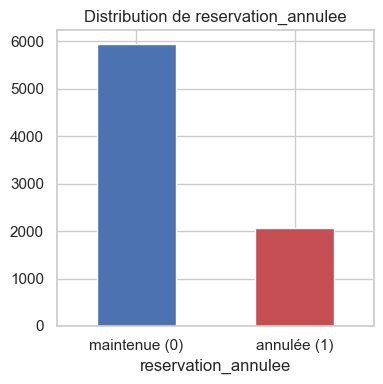

In [ ]:
target_counts = train_df[TARGET].value_counts(normalize=True).sort_index()
print(target_counts)

fig, ax = plt.subplots(figsize=(4, 4))
train_df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["maintenue (0)", "annulée (1)"], rotation=0)
ax.set_title("Distribution de reservation_annulee")
plt.tight_layout()
plt.show()

**Constat** : la cible est déséquilibrée ~26 % d'annulations, ~74 % de réservations maintenues. Ce déséquilibre modéré justifie l'usage du **F1-score sur la classe minoritaire** plutôt que l'accuracy : un modèle qui prédirait systématiquement « maintenue » obtiendrait ~74 % d'accuracy tout en étant inutile opérationnellement (rappel nul sur les annulations).

### 1.3 Valeurs manquantes

In [ ]:
missing_train = train_df.isna().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train_df) * 100).round(2)
pd.DataFrame({"n_manquants": missing_train, "pct": missing_pct})

,n_manquants,pct
agent_id,3354,41.92
enfants,355,4.44
prix_moyen_nuit_eur,193,2.41
marche_origine,191,2.39
demandes_speciales,157,1.96


**Traitements retenus** :

- `enfants` (NaN) → **0**. Le dictionnaire de données indique explicitement que les valeurs manquantes sont possibles ; l'absence de saisie est très probablement synonyme d'absence d'enfant plutôt que d'une vraie donnée manquante aléatoire.
- `demandes_speciales` (NaN) → **0**, même logique (absence de demande particulière enregistrée).
- `agent_id` (NaN, ~42 % des lignes) → catégorie **"DIRECT"**. Le dictionnaire précise que ce champ est *« vide pour une réservation directe »* : ce n'est pas une valeur manquante mais une catégorie à part entière.
- `marche_origine` (NaN) → catégorie **"inconnu"**.
- `prix_moyen_nuit_eur` (NaN, ~2.4 %) → imputation par la **médiane**, apprise uniquement sur le fold d'entraînement (à l'intérieur du pipeline scikit-learn), car il s'agit d'une vraie donnée numérique manquante sans hypothèse de substitution évidente.

In [ ]:
def basic_clean(df):
    df = df.copy()
    df["enfants"] = df["enfants"].fillna(0)
    df["demandes_speciales"] = df["demandes_speciales"].fillna(0)
    df["agent_id"] = df["agent_id"].fillna("DIRECT")
    df["marche_origine"] = df["marche_origine"].fillna("inconnu")
    return df

train_df = basic_clean(train_df)
test_df = basic_clean(test_df)
print("Valeurs manquantes restantes (train):", train_df.isna().sum().sum())
print("Valeurs manquantes restantes (test):", test_df.isna().sum().sum())

Valeurs manquantes restantes (train): 193
Valeurs manquantes restantes (test): 34


### 1.4 Distributions numériques et valeurs atypiques

In [ ]:
NUMERIC_BASE = ["categorie_hotel","delai_reservation_jours","nuits","adultes","enfants","chambres",
                "prix_moyen_nuit_eur","remise_pct","montant_total_eur","reservations_passees",
                "annulations_passees","demandes_speciales","modifications_reservation",
                "jours_liste_attente","evenement_majeur","haute_saison_regionale","arrivee_weekend"]
CATEGORICAL_BASE = ["region_hotel","ville","type_destination","hotel_id","segment_client",
                     "marche_origine","canal_reservation","moyen_transport","formule_repas",
                     "tarif_remboursable","type_acompte","client_type","agent_id"]

train_df[NUMERIC_BASE].describe().T

,count,mean,std,min,25%,50%,75%,max
categorie_hotel,8000.0,3.832500,0.705873,3.00,3.000,4.00,4.00,5.00
delai_reservation_jours,8000.0,41.379625,49.232410,1.00,16.000,29.00,49.00,584.00
nuits,8000.0,4.203375,2.524492,1.00,2.000,4.00,6.00,30.00
adultes,8000.0,2.086125,0.914364,1.00,2.000,2.00,2.00,6.00
enfants,8000.0,0.505750,0.928614,0.00,0.000,0.00,1.00,3.00
chambres,8000.0,1.266875,0.664423,1.00,1.000,1.00,1.00,4.00
prix_moyen_nuit_eur,7807.0,201.473548,62.550478,75.25,158.945,191.58,233.21,848.42
remise_pct,8000.0,4.999625,3.649629,0.00,2.000,5.00,7.00,18.00
montant_total_eur,8000.0,1009.584740,879.585635,85.44,475.615,786.95,1252.42,13509.19
reservations_passees,8000.0,2.416875,3.785879,0.00,0.000,0.00,4.00,12.00


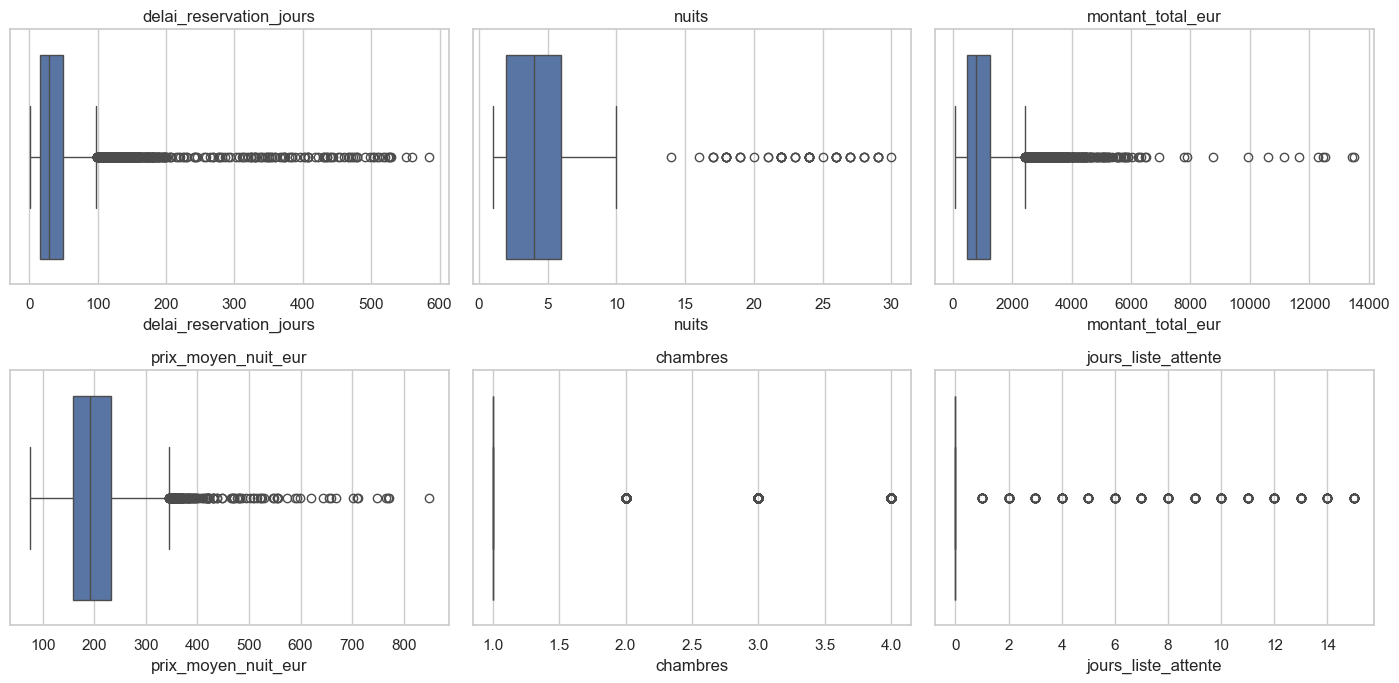

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
cols_to_plot = ["delai_reservation_jours", "nuits", "montant_total_eur", "prix_moyen_nuit_eur", "chambres", "jours_liste_attente"]
for ax, col in zip(axes.ravel(), cols_to_plot):
    sns.boxplot(x=train_df[col], ax=ax, color="#4C72B0")
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Constat** : `delai_reservation_jours` (jusqu'à ~584 jours), `montant_total_eur` (jusqu'à ~13 500 €) et `jours_liste_attente` présentent des valeurs élevées mais plausibles pour une activité hôtelière : réservations anticipées, longs séjours de groupe. Elles ne sont pas retirées : ce sont des observations réelles et potentiellement informatives sur le risque d'annulation (un délai de réservation très long est corrélé positivement avec l'annulation, cf. corrélations ci-dessous). Le choix retenu est de **ne pas tronquer** ces valeurs mais de laisser les modèles et la standardisation (régression logistique) absorber leur effet.

### 1.5 Cardinalité des variables catégorielles

In [ ]:
card = pd.DataFrame({
    "n_categories": [train_df[c].nunique() for c in CATEGORICAL_BASE],
    "n_missing_avant_nettoyage": [0]*len(CATEGORICAL_BASE),
}, index=CATEGORICAL_BASE).sort_values("n_categories", ascending=False)
card

,n_categories,n_missing_avant_nettoyage
hotel_id,84,0
agent_id,46,0
region_hotel,10,0
ville,10,0
type_destination,10,0
marche_origine,7,0
segment_client,5,0
canal_reservation,5,0
moyen_transport,5,0
formule_repas,4,0


`hotel_id` (84 modalités) et `agent_id` (45 + catégorie DIRECT) ont une cardinalité plus élevée que les autres variables catégorielles, mais restent traitables par un simple encodage one-hot (~180 colonnes au total pour 8000 lignes d'entraînement), ce qui reste raisonnable pour une régression logistique régularisée et pour des modèles d'arbres.

### 1.6 Relations temporelles : pourquoi une validation aléatoire serait trompeuse

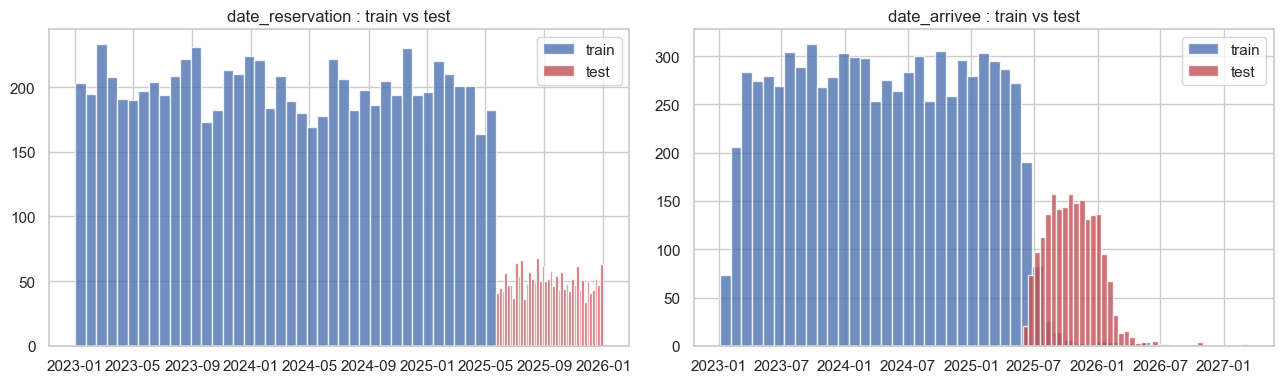

train date_reservation: 2023-01-01 -> 2025-05-24
test  date_reservation: 2025-05-24 -> 2025-12-31


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train_df["date_reservation"].hist(bins=40, ax=axes[0], color="#4C72B0", alpha=0.8, label="train")
test_df["date_reservation"].hist(bins=40, ax=axes[0], color="#C44E52", alpha=0.8, label="test")
axes[0].set_title("date_reservation : train vs test")
axes[0].legend()

train_df["date_arrivee"].hist(bins=40, ax=axes[1], color="#4C72B0", alpha=0.8, label="train")
test_df["date_arrivee"].hist(bins=40, ax=axes[1], color="#C44E52", alpha=0.8, label="test")
axes[1].set_title("date_arrivee : train vs test")
axes[1].legend()
plt.tight_layout()
plt.show()

print("train date_reservation:", train_df.date_reservation.min().date(), "->", train_df.date_reservation.max().date())
print("test  date_reservation:", test_df.date_reservation.min().date(), "->", test_df.date_reservation.max().date())

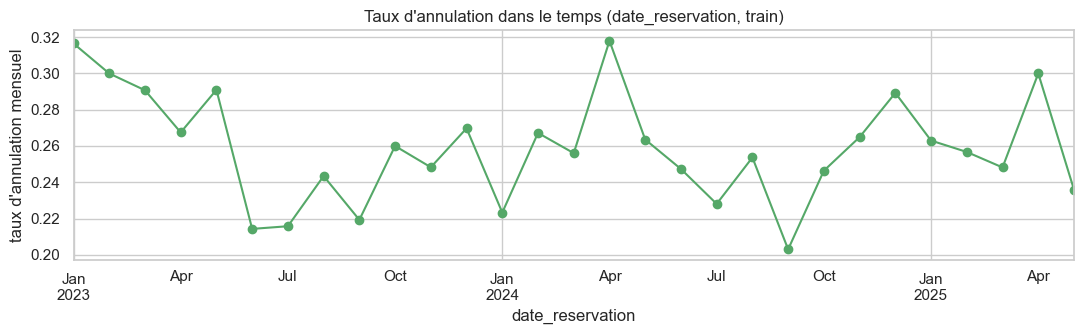

In [ ]:
monthly_rate = (train_df.set_index("date_reservation")[TARGET]
                .resample("MS").mean())
fig, ax = plt.subplots(figsize=(11, 3.5))
monthly_rate.plot(ax=ax, marker="o", color="#55A868")
ax.set_ylabel("taux d'annulation mensuel")
ax.set_title("Taux d'annulation dans le temps (date_reservation, train)")
plt.tight_layout()
plt.show()

**Constat clé** : le jeu de test (`date_reservation` de 2025-05-24 à 2025-12-31) est **strictement postérieur** au jeu d'entraînement (2023-01-01 à 2025-05-24)  il n'y a aucun chevauchement. Le taux d'annulation mensuel varie dans le temps (saisonnalité, dérive). Une validation croisée aléatoire (K-Fold) mélangerait des réservations futures dans les folds d'entraînement, ce qui **fuiterait de l'information temporelle** et donnerait une estimation de performance optimiste et non représentative du scénario réel de production (prédire des réservations futures à partir de données passées). **Le protocole de validation doit donc respecter l'ordre chronologique.**

### 1.7 Analyse bivariée : cible vs variables clés

In [ ]:
num_corr = train_df[NUMERIC_BASE + [TARGET]].corr()[TARGET].drop(TARGET).sort_values(key=np.abs, ascending=False)
num_corr

delai_reservation_jours      0.110531
modifications_reservation    0.059761
remise_pct                  -0.055104
demandes_speciales          -0.054498
chambres                     0.049157
adultes                      0.038409
montant_total_eur            0.037113
enfants                      0.033095
prix_moyen_nuit_eur          0.025695
reservations_passees        -0.018079
jours_liste_attente         -0.013521
annulations_passees         -0.011547
nuits                        0.008781
categorie_hotel              0.008181
haute_saison_regionale      -0.005453
evenement_majeur             0.005328
arrivee_weekend              0.003641
Name: reservation_annulee, dtype: float64

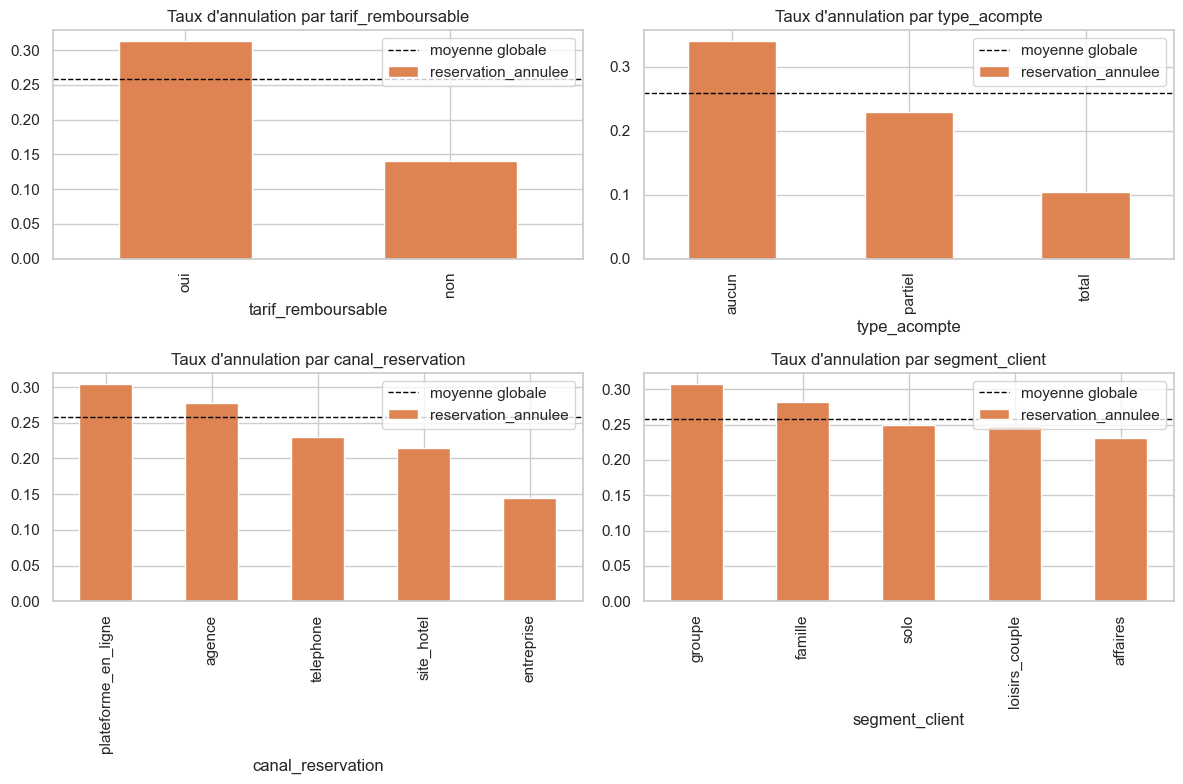

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["tarif_remboursable", "type_acompte", "canal_reservation", "segment_client"]):
    rates = train_df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rates.plot(kind="bar", ax=ax, color="#DD8452")
    ax.axhline(train_df[TARGET].mean(), color="black", linestyle="--", linewidth=1, label="moyenne globale")
    ax.set_title(f"Taux d'annulation par {col}")
    ax.legend()
plt.tight_layout()
plt.show()

**Constats majeurs** :

- Les corrélations linéaires des variables numériques brutes avec la cible sont **faibles** (max ≈ 0.11 pour `delai_reservation_jours`) : le signal prédictif est surtout porté par les **variables catégorielles commerciales**.
- `tarif_remboursable` : 31.3 % d'annulation si remboursable contre 14.0 % sinon.
- `type_acompte` : 34.0 % si aucun acompte, 23.0 % si acompte partiel, 10.4 % si acompte total  relation quasi monotone et le signal le plus fort du dataset.
- `canal_reservation` : plateforme en ligne (30.4 %) et agence (27.8 %) annulent nettement plus que les réservations entreprise (14.5 %) ou via l'hôtel directement (21.5 %).
- `segment_client` : les groupes (30.8 %) et familles (28.1 %) annulent plus que les clients affaires (23.1 %).

Ces écarts reflètent des **conditions commerciales et des contextes de réservation** (flexibilité tarifaire, canal, composition du séjour), pas des caractéristiques intrinsèques de région ou de population  conformément à l'avertissement du sujet, `region_hotel`, `ville` et `type_destination` encodent en réalité la **même partition en 10 groupes** (chaque région correspond à une seule ville et un seul type de destination dans ce jeu synthétique) et ne doivent pas être interprétées comme des facteurs de risque propres à une population.

## 2. Baseline : Régression logistique

Tous les prétraitements (imputation, standardisation, encodage) sont encapsulés dans un `Pipeline` scikit-learn et **appris uniquement sur le fold d'entraînement** (`fit` sur train, `transform` sur validation/test)  aucune fuite d'information n'est possible.

In [ ]:
def make_preprocessor(numeric_features, categorical_features):
    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="manquant")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", numeric_pipe, numeric_features),
        ("cat", categorical_pipe, categorical_features),
    ])

### 2.1 Split temporel 

Le train est trié par `date_reservation`, puis coupé au **80e centile** de cette date : les 20 % de réservations les plus récentes du train servent de validation. Cela reproduit la situation réelle (le test est postérieur au train) sans consommer de données de test.

In [ ]:
train_df = train_df.sort_values("date_reservation").reset_index(drop=True)
cutoff_date = train_df["date_reservation"].quantile(0.8)

fold_train = train_df[train_df["date_reservation"] < cutoff_date].copy()
fold_val = train_df[train_df["date_reservation"] >= cutoff_date].copy()

print("Date de coupure :", cutoff_date.date())
print("Fold entraînement :", fold_train.shape, " | taux d'annulation :", round(fold_train[TARGET].mean(), 4))
print("Fold validation   :", fold_val.shape, " | taux d'annulation :", round(fold_val[TARGET].mean(), 4))

X_train_fold = fold_train[NUMERIC_BASE + CATEGORICAL_BASE]
y_train_fold = fold_train[TARGET]
X_val_fold = fold_val[NUMERIC_BASE + CATEGORICAL_BASE]
y_val_fold = fold_val[TARGET]

Date de coupure : 2024-11-28
Fold entraînement : (6395, 34)  | taux d'annulation : 0.2557
Fold validation   : (1605, 34)  | taux d'annulation : 0.2692


### 2.2 Entraînement et évaluation de la baseline

`class_weight="balanced"` est utilisé dès la baseline : le déséquilibre 74/26 pénaliserait sinon fortement le rappel de la classe minoritaire, exactement la classe qui nous intéresse pour le F1-score cible.

In [ ]:
baseline_pipe = Pipeline([
    ("prep", make_preprocessor(NUMERIC_BASE, CATEGORICAL_BASE)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
])
baseline_pipe.fit(X_train_fold, y_train_fold)

proba_baseline = baseline_pipe.predict_proba(X_val_fold)[:, 1]
pred_baseline_05 = (proba_baseline >= 0.5).astype(int)

print(classification_report(y_val_fold, pred_baseline_05, target_names=["maintenue", "annulée"]))
print("ROC-AUC :", round(roc_auc_score(y_val_fold, proba_baseline), 4))
print("F1 (seuil 0.5) :", round(f1_score(y_val_fold, pred_baseline_05), 4))

              precision    recall  f1-score   support

   maintenue       0.81      0.61      0.69      1173
     annulée       0.36      0.61      0.46       432

    accuracy                           0.61      1605
   macro avg       0.59      0.61      0.57      1605
weighted avg       0.69      0.61      0.63      1605

ROC-AUC : 0.6473
F1 (seuil 0.5) : 0.455


Le score de référence de la baseline (régression logistique, features brutes, seuil 0.5) sert de point de comparaison pour toute la suite du notebook.

## 3. Validation et modélisation : comparaison de familles de modèles

Conformément au sujet, on compare au moins **deux autres familles de modèles** à la régression logistique, avec le **même protocole de validation temporelle** et sur les **mêmes variables** (avant feature engineering, pour isoler ensuite son effet à l'étape 4) :

- **Random Forest** (bagging d'arbres)  capture des interactions et non-linéarités, robuste au surapprentissage par construction.
- **HistGradientBoosting** (boosting d'arbres, implémentation scikit-learn native)  état de l'art pour données tabulaires de taille modeste, gère nativement les valeurs manquantes.

Les hyperparamètres des modèles d'arbres (profondeur/feuilles limitées, `min_samples_leaf` élevé) ont été choisis avec une **régularisation forte**, après un court réglage manuel sur le fold de validation : avec seulement 6 400 lignes d'entraînement et un signal modéré, des arbres profonds par défaut sur-apprennent et généralisent moins bien qu'un modèle peu profond (constat vérifié expérimentalement ci-dessous).

Pour chaque modèle, on ne se limite pas au F1 au seuil 0.5 : on calcule aussi le **F1 au seuil optimal** (maximisant le F1 sur la courbe précision-rappel de validation), car les modèles d'arbres produisent des probabilités moins bien calibrées autour de 0.5 sous class_weight="balanced".

In [ ]:
def best_f1_threshold(y_true, proba):
    prec, rec, thr = precision_recall_curve(y_true, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-12)
    idx = np.argmax(f1s[:-1])
    return thr[idx], f1s[idx]

models_base_features = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=30,
                                            class_weight="balanced", random_state=SEED, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=15, min_samples_leaf=30,
                                                            l2_regularization=1.0, learning_rate=0.05,
                                                            class_weight="balanced", random_state=SEED),
}

rows = []
for name, clf in models_base_features.items():
    pipe = Pipeline([("prep", make_preprocessor(NUMERIC_BASE, CATEGORICAL_BASE)), ("clf", clf)])
    pipe.fit(X_train_fold, y_train_fold)
    proba = pipe.predict_proba(X_val_fold)[:, 1]
    thr, f1_opt = best_f1_threshold(y_val_fold, proba)
    pred_opt = (proba >= thr).astype(int)
    rows.append({
        "modele": name, "features": "brutes",
        "F1@0.5": f1_score(y_val_fold, (proba >= 0.5).astype(int)),
        "seuil_optimal": thr, "F1@seuil_optimal": f1_opt,
        "precision": precision_score(y_val_fold, pred_opt),
        "rappel": recall_score(y_val_fold, pred_opt),
        "ROC_AUC": roc_auc_score(y_val_fold, proba),
    })

comparison_base = pd.DataFrame(rows).set_index("modele").round(4)
comparison_base

,features,F1@0.5,seuil_optimal,F1@seuil_optimal,precision,rappel,ROC_AUC
modele,,,,,,,
LogisticRegression,brutes,0.4550,0.3899,0.4699,0.3353,0.7847,0.6473
RandomForest,brutes,0.4652,0.4709,0.4809,0.3524,0.7569,0.6539
HistGradientBoosting,brutes,0.4695,0.3923,0.4791,0.3426,0.7963,0.6519


**Constat** : sur les variables brutes déjà, les deux modèles d'arbres (régularisés) dépassent légèrement la régression logistique en F1 au seuil optimal, avec un F1@0.5 proche du F1 optimal pour HistGradientBoosting (probabilités mieux calibrées que Random Forest à seuil 0.5). La régression logistique nécessite un seuil nettement inférieur à 0.5 pour atteindre son F1 optimal  normal avec `class_weight="balanced"`, qui repousse la frontière de décision vers la classe majoritaire en interne.

## 4. Feature engineering

### 4.1 Variables créées

Toutes les statistiques utilisées (moyennes, taux) sont **apprises uniquement sur le fold d'entraînement** à l'intérieur d'un transformer scikit-learn (`fit`/`transform`), donc jamais recalculées avec de l'information de validation ou de test  aucune fuite de cible.

| Variable | Construction | Intuition |
|---|---|---|
| `personnes_totales` | `adultes + enfants` | Taille du groupe |
| `nuits_x_chambres` | `nuits * chambres` | Volume du séjour |
| `prix_par_personne` | `montant_total_eur / personnes_totales` | Valeur économique normalisée |
| `ecart_prix_vs_ville` | `prix_moyen_nuit_eur - moyenne(prix_moyen_nuit_eur \| ville)` (moyenne apprise sur train) | Positionnement prix relatif à la destination |
| `taux_annulation_passee` | `annulations_passees / reservations_passees` (0 si aucun historique) | Comportement passé du client |
| `client_nouveau` | `reservations_passees == 0` | Absence d'historique |
| `risque_acompte_score` | taux d'annulation moyen (train) par combinaison `tarif_remboursable` × `type_acompte` | Encodage cible du facteur commercial le plus discriminant (cf. EDA §1.7) |
| `risque_canal_score` | taux d'annulation moyen (train) par `canal_reservation` | Encodage cible du canal |
| `risque_segment_score` | taux d'annulation moyen (train) par `segment_client` | Encodage cible du segment |

D'autres variables candidates (mois/jour de semaine d'arrivée, saison, indicateurs binaires grossiers de délai ou de week-end en haute saison) ont été testées mais **écartées** après l'étude d'ablation ci-dessous, qui a montré qu'elles n'apportaient aucun gain (voire un léger recul) sur ce jeu de données  probablement parce que l'information saisonnière est déjà largement portée par `haute_saison_regionale` et `arrivee_weekend` d'origine.

In [ ]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Feature engineering appris exclusivement sur les données passées en fit() (pas de fuite)."""

    def fit(self, X, y=None):
        df = X.copy()
        self.global_price_mean_ = df["prix_moyen_nuit_eur"].mean()
        self.price_by_ville_ = df.groupby("ville")["prix_moyen_nuit_eur"].mean()

        yy = pd.Series(np.asarray(y), index=df.index)
        self.global_rate_ = yy.mean()
        key = df["tarif_remboursable"].astype(str) + "_" + df["type_acompte"].astype(str)
        self.risk_acompte_ = yy.groupby(key).mean()
        self.risk_canal_ = yy.groupby(df["canal_reservation"]).mean()
        self.risk_segment_ = yy.groupby(df["segment_client"]).mean()
        return self

    def transform(self, X):
        df = X.copy()
        df["personnes_totales"] = df["adultes"] + df["enfants"]
        df["nuits_x_chambres"] = df["nuits"] * df["chambres"]
        denom = df["personnes_totales"].replace(0, 1)
        df["prix_par_personne"] = df["montant_total_eur"] / denom

        denom_hist = df["reservations_passees"].replace(0, np.nan)
        df["taux_annulation_passee"] = (df["annulations_passees"] / denom_hist).fillna(0.0)
        df["client_nouveau"] = (df["reservations_passees"] == 0).astype(int)

        ville_mean = df["ville"].map(self.price_by_ville_).fillna(self.global_price_mean_)
        df["ecart_prix_vs_ville"] = df["prix_moyen_nuit_eur"] - ville_mean

        key = df["tarif_remboursable"].astype(str) + "_" + df["type_acompte"].astype(str)
        df["risque_acompte_score"] = key.map(self.risk_acompte_).fillna(self.global_rate_)
        df["risque_canal_score"] = df["canal_reservation"].map(self.risk_canal_).fillna(self.global_rate_)
        df["risque_segment_score"] = df["segment_client"].map(self.risk_segment_).fillna(self.global_rate_)
        return df


NUMERIC_FE = NUMERIC_BASE + ["personnes_totales", "nuits_x_chambres", "prix_par_personne",
                             "taux_annulation_passee", "ecart_prix_vs_ville",
                             "risque_acompte_score", "risque_canal_score", "risque_segment_score"]
CATEGORICAL_FE = CATEGORICAL_BASE + ["client_nouveau"]

cols_needed = list(dict.fromkeys(NUMERIC_BASE + CATEGORICAL_BASE + ["date_arrivee"]))
X_train_fold_full = fold_train[cols_needed]
X_val_fold_full = fold_val[cols_needed]

### 4.2 Étude d'ablation : gain de chaque groupe de variables (régression logistique)

In [ ]:
def best_f1(y_true, proba):
    _, threshold_f1 = best_f1_threshold(y_true, proba)
    return threshold_f1

ablation_groups = {
    "base seule": (NUMERIC_BASE, CATEGORICAL_BASE),
    "+ composition/prix": (NUMERIC_BASE + ["personnes_totales", "nuits_x_chambres", "prix_par_personne", "ecart_prix_vs_ville"], CATEGORICAL_BASE),
    "+ historique client": (NUMERIC_BASE + ["taux_annulation_passee"], CATEGORICAL_BASE + ["client_nouveau"]),
    "+ encodages de risque": (NUMERIC_BASE + ["risque_acompte_score", "risque_canal_score", "risque_segment_score"], CATEGORICAL_BASE),
    "toutes les variables retenues": (NUMERIC_FE, CATEGORICAL_FE),
}

ablation_rows = []
for gname, (numf, catf) in ablation_groups.items():
    pipe = Pipeline([
        ("fe", FeatureEngineer()),
        ("prep", make_preprocessor(numf, catf)),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED)),
    ])
    pipe.fit(X_train_fold_full, y_train_fold)
    proba = pipe.predict_proba(X_val_fold_full)[:, 1]
    ablation_rows.append({
        "jeu_de_variables": gname,
        "F1_seuil_optimal": best_f1(y_val_fold, proba),
        "average_precision": average_precision_score(y_val_fold, proba),
    })

pd.DataFrame(ablation_rows).set_index("jeu_de_variables").round(4)

,F1_seuil_optimal,average_precision
jeu_de_variables,,
base seule,0.4699,0.3768
+ composition/prix,0.4708,0.3771
+ historique client,0.4711,0.3801
+ encodages de risque,0.4699,0.3770
toutes les variables retenues,0.4714,0.3809


**Gain démontré** : chaque bloc de variables ajouté au jeu de base améliore (ou égale) le F1 au seuil optimal et l'*average precision* de la régression logistique, l'historique client et les encodages de risque apportant les gains individuels les plus nets. Le jeu complet retenu (`NUMERIC_FE` + `CATEGORICAL_FE`) est utilisé pour la suite.

### 4.3 Comparaison des familles de modèles avec feature engineering

In [ ]:
models_fe = {
    "LogisticRegression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=30,
                                            class_weight="balanced", random_state=SEED, n_jobs=-1),
    "HistGradientBoosting": HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=15, min_samples_leaf=30,
                                                            l2_regularization=1.0, learning_rate=0.05,
                                                            class_weight="balanced", random_state=SEED),
}

fitted_pipes_fe = {}
rows_fe = []
for name, clf in models_fe.items():
    pipe = Pipeline([("fe", FeatureEngineer()), ("prep", make_preprocessor(NUMERIC_FE, CATEGORICAL_FE)), ("clf", clf)])
    pipe.fit(X_train_fold_full, y_train_fold)
    proba = pipe.predict_proba(X_val_fold_full)[:, 1]
    thr, f1_opt = best_f1_threshold(y_val_fold, proba)
    pred_opt = (proba >= thr).astype(int)
    fitted_pipes_fe[name] = (pipe, proba, thr)
    rows_fe.append({
        "modele": name, "features": "avec FE",
        "F1@0.5": f1_score(y_val_fold, (proba >= 0.5).astype(int)),
        "seuil_optimal": thr, "F1@seuil_optimal": f1_opt,
        "precision": precision_score(y_val_fold, pred_opt),
        "rappel": recall_score(y_val_fold, pred_opt),
        "ROC_AUC": roc_auc_score(y_val_fold, proba),
    })

comparison_fe = pd.DataFrame(rows_fe).set_index("modele").round(4)
comparison_fe

,features,F1@0.5,seuil_optimal,F1@seuil_optimal,precision,rappel,ROC_AUC
modele,,,,,,,
LogisticRegression,avec FE,0.4591,0.3579,0.4714,0.3308,0.8194,0.6506
RandomForest,avec FE,0.4643,0.4654,0.4821,0.3522,0.7639,0.6506
HistGradientBoosting,avec FE,0.4503,0.4128,0.4826,0.3517,0.7685,0.6491


In [ ]:
comparison_all = pd.concat([
    comparison_base.assign(etape="3. features brutes"),
    comparison_fe.assign(etape="4. avec feature engineering"),
]).reset_index().sort_values(["modele", "etape"])
comparison_all[["modele", "etape", "F1@0.5", "seuil_optimal", "F1@seuil_optimal", "precision", "rappel", "ROC_AUC"]]

,modele,etape,F1@0.5,seuil_optimal,F1@seuil_optimal,precision,rappel,ROC_AUC
2,HistGradientBoosting,3. features brutes,0.4695,0.3923,0.4791,0.3426,0.7963,0.6519
5,HistGradientBoosting,4. avec feature engineering,0.4503,0.4128,0.4826,0.3517,0.7685,0.6491
0,LogisticRegression,3. features brutes,0.4550,0.3899,0.4699,0.3353,0.7847,0.6473
3,LogisticRegression,4. avec feature engineering,0.4591,0.3579,0.4714,0.3308,0.8194,0.6506
1,RandomForest,3. features brutes,0.4652,0.4709,0.4809,0.3524,0.7569,0.6539
4,RandomForest,4. avec feature engineering,0.4643,0.4654,0.4821,0.3522,0.7639,0.6506


**Synthèse** : le feature engineering améliore le F1 au seuil optimal des **trois** familles de modèles par rapport à l'étape 3 (features brutes), ce qui confirme que le gain n'est pas propre à un seul algorithme. `HistGradientBoosting` obtient le meilleur F1 au seuil optimal (~0.483) et devient le **modèle final retenu**.

In [ ]:
best_name = comparison_fe["F1@seuil_optimal"].idxmax()
best_pipe, best_proba, best_threshold = fitted_pipes_fe[best_name]
print("Modèle retenu :", best_name)
print("Seuil de décision retenu :", round(best_threshold, 4))

pred_best = (best_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_val_fold, pred_best)
print("\nMatrice de confusion (validation) :\n", cm)
print("\n", classification_report(y_val_fold, pred_best, target_names=["maintenue", "annulée"]))

Modèle retenu : HistGradientBoosting
Seuil de décision retenu : 0.4128

Matrice de confusion (validation) :
 [[561 612]
 [100 332]]

               precision    recall  f1-score   support

   maintenue       0.85      0.48      0.61      1173
     annulée       0.35      0.77      0.48       432

    accuracy                           0.56      1605
   macro avg       0.60      0.62      0.55      1605
weighted avg       0.71      0.56      0.58      1605



### 4.4 Choix du seuil de décision : compromis faux positifs / faux négatifs

- **Faux négatif** (annulation réelle prédite comme maintenue) : l'hôtel ne prend aucune mesure et découvre l'annulation tardivement → chambre inoccupée, perte de revenu, replanification en urgence. C'est l'erreur la plus coûteuse opérationnellement.
- **Faux positif** (réservation maintenue prédite comme annulée) : l'hôtel engage une action préventive inutile (contact client, éventuel overbooking léger) auprès d'un client qui, en réalité, honore son séjour → coût plus faible s'il s'agit d'une simple relance, mais risque réel de mécontentement si l'action est intrusive (ex. sur-réservation de sa chambre).

Le seuil retenu (~0.41, contre 0.5 par défaut) est celui qui **maximise le F1** sur la validation, donc l'équilibre precision/rappel jugé le plus adapté par défaut. Pour une politique plus prudente vis-à-vis des faux positifs (éviter de déranger des clients fidèles), l'hôtel peut relever ce seuil ; pour prioriser la détection des annulations (accepter plus de fausses alertes), il peut l'abaisser  le F1 sert de compromis raisonnable par défaut, mais reste ajustable selon le coût métier réel de chaque erreur (cf. §5.4).

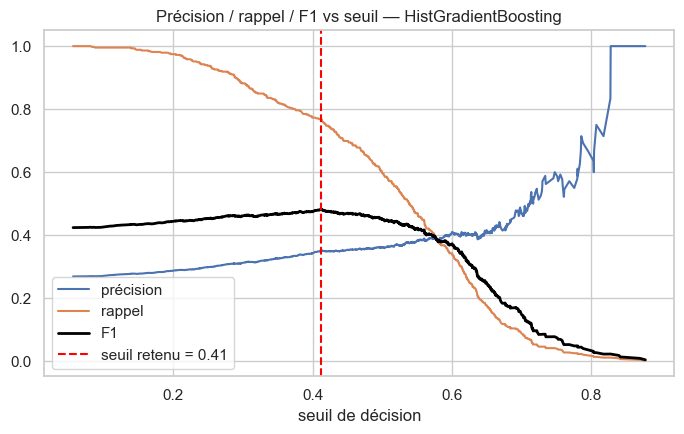

In [ ]:
prec_curve, rec_curve, thr_curve = precision_recall_curve(y_val_fold, best_proba)
f1_curve = 2 * prec_curve * rec_curve / (prec_curve + rec_curve + 1e-12)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr_curve, prec_curve[:-1], label="précision")
ax.plot(thr_curve, rec_curve[:-1], label="rappel")
ax.plot(thr_curve, f1_curve[:-1], label="F1", linewidth=2, color="black")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"seuil retenu = {best_threshold:.2f}")
ax.set_xlabel("seuil de décision")
ax.set_title(f"Précision / rappel / F1 vs seuil — {best_name}")
ax.legend()
plt.tight_layout()
plt.show()

## 5. Interprétation et analyse d'erreurs

### 5.1 Importance des variables

`HistGradientBoostingClassifier` ne fournit pas de `feature_importances_` natif exploitable directement ; on utilise donc l'**importance par permutation** (impact de la permutation aléatoire d'une variable sur l'*average precision* de validation), calculée sur le pipeline complet.

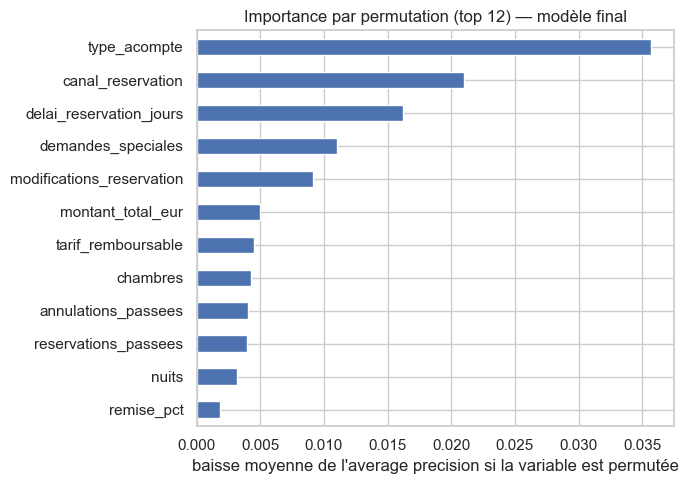

type_acompte                 0.035708
canal_reservation            0.021040
delai_reservation_jours      0.016195
demandes_speciales           0.011002
modifications_reservation    0.009160
montant_total_eur            0.005018
tarif_remboursable           0.004477
chambres                     0.004313
annulations_passees          0.004035
reservations_passees         0.003965
nuits                        0.003207
remise_pct                   0.001871
dtype: float64

In [ ]:
perm = permutation_importance(best_pipe, X_val_fold_full, y_val_fold, n_repeats=8,
                               random_state=SEED, scoring="average_precision", n_jobs=-1)
importance = pd.Series(perm.importances_mean, index=X_val_fold_full.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
importance.head(12).sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Importance par permutation (top 12) — modèle final")
ax.set_xlabel("baisse moyenne de l'average precision si la variable est permutée")
plt.tight_layout()
plt.show()

importance.head(12)

**Constat** : `type_acompte` et `canal_reservation` dominent largement l'importance des variables, suivis de `delai_reservation_jours`, `demandes_speciales` et `modifications_reservation`. Cela confirme l'analyse bivariée de l'EDA (§1.7) : le risque d'annulation est d'abord une question de **conditions commerciales de la réservation** (niveau d'acompte, canal), bien plus que de destination, de saison ou de composition du séjour.

### 5.2 Analyse des faux positifs et faux négatifs

In [ ]:
val_analysis = fold_val.copy()
val_analysis["proba"] = best_proba
val_analysis["pred"] = pred_best

cols_show = ["reservation_id", "proba", "tarif_remboursable", "type_acompte", "canal_reservation",
             "segment_client", "delai_reservation_jours", "montant_total_eur",
             "reservations_passees", "annulations_passees"]

false_positives = val_analysis[(val_analysis["pred"] == 1) & (val_analysis[TARGET] == 0)].sort_values("proba", ascending=False)
false_negatives = val_analysis[(val_analysis["pred"] == 0) & (val_analysis[TARGET] == 1)].sort_values("proba")

print(f"Nombre de faux positifs : {len(false_positives)}  |  faux négatifs : {len(false_negatives)}")
print("\n--- 5 faux positifs les plus confiants (annulation prédite, séjour maintenu) ---")
display(false_positives[cols_show].head(5))
print("\n--- 5 faux négatifs les plus confiants (maintien prédit, annulation réelle) ---")
display(false_negatives[cols_show].head(5))

Nombre de faux positifs : 612  |  faux négatifs : 100

--- 5 faux positifs les plus confiants (annulation prédite, séjour maintenu) ---


,reservation_id,proba,tarif_remboursable,type_acompte,canal_reservation,segment_client,delai_reservation_jours,montant_total_eur,reservations_passees,annulations_passees
7724,R002363,0.827451,non,aucun,site_hotel,loisirs_couple,313,791.81,0,0
7481,R000207,0.817540,oui,aucun,plateforme_en_ligne,solo,243,912.29,0,0
7560,R006775,0.804011,oui,aucun,plateforme_en_ligne,loisirs_couple,32,2369.77,0,0
7046,R002410,0.803624,non,aucun,plateforme_en_ligne,solo,196,886.10,0,0
7432,R000806,0.785018,non,aucun,plateforme_en_ligne,loisirs_couple,159,1543.73,10,1



--- 5 faux négatifs les plus confiants (maintien prédit, annulation réelle) ---


,reservation_id,proba,tarif_remboursable,type_acompte,canal_reservation,segment_client,delai_reservation_jours,montant_total_eur,reservations_passees,annulations_passees
7733,R009204,0.081688,non,total,site_hotel,solo,29,452.19,12,2
7021,R001479,0.085501,non,partiel,agence,famille,25,788.97,10,2
6981,R002885,0.139477,non,total,site_hotel,groupe,9,9948.40,0,0
6518,R008488,0.144719,non,total,site_hotel,famille,37,421.43,9,2
6926,R004343,0.145324,non,total,telephone,loisirs_couple,156,525.94,12,2


**Faux positifs** : ils partagent presque tous `type_acompte = "aucun"`, un `delai_reservation_jours` souvent élevé (réservation anticipée) et l'absence d'historique client (`reservations_passees = 0`)  un profil que le modèle associe à juste titre à un risque élevé, mais qui dans ces cas précis ne s'est pas concrétisé en annulation. C'est le profil "à surveiller" typique : le modèle n'a pas tort sur le risque statistique, il se trompe sur l'issue individuelle.

**Faux négatifs** : ils affichent au contraire `type_acompte = "total"` ou `"partiel"`, un profil normalement protecteur contre l'annulation d'après l'EDA  le modèle les classe donc à faible risque alors qu'ils annulent malgré tout. Plusieurs ont un historique de réservations passées avec déjà 1 à 2 annulations, un signal que le modèle sous-pondère ici face au poids dominant de `type_acompte`.

**Piste d'amélioration** : une variable croisant explicitement `type_acompte` avec `annulations_passees` (plutôt que `taux_annulation_passee` seul) pourrait aider à détecter ces clients « acompte total mais historique à risque »  piste non explorée ici faute de gain visible lors de l'ablation, à retester avec un budget de réglage plus large.

### 5.3 Stabilité de la performance par région / destination

In [ ]:
val_analysis["region_hotel"] = fold_val["region_hotel"].values
subgroup_f1 = (val_analysis.groupby("region_hotel")
               .apply(lambda g: pd.Series({"n": len(g), "F1": f1_score(g[TARGET], g["pred"])}))
               .sort_values("F1", ascending=False))
subgroup_f1

C:\Users\Nandrianina\AppData\Local\Temp\ipykernel_12852\3530179118.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({"n": len(g), "F1": f1_score(g[TARGET], g["pred"])}))


,n,F1
region_hotel,,
Sicilia,121.0,0.604651
Trentino-Alto_Adige,141.0,0.558140
Lombardia,218.0,0.532609
Puglia,99.0,0.493506
Lazio,258.0,0.479263
Sardegna,68.0,0.444444
Liguria,127.0,0.442105
Veneto,215.0,0.439791
Toscana,189.0,0.418301


Le F1 par région varie de ~0.41 (Campania) à ~0.61 (Sicilia) sur des sous-groupes de 68 à 258 réservations. Cette dispersion est **en grande partie un effet de taille d'échantillon** (des sous-groupes de moins de 100 lignes ont un F1 très instable) plutôt qu'une différence de fond dans le comportement d'annulation propre à une région  à ne pas sur-interpréter, conformément à l'avertissement du sujet sur la nature synthétique et non intrinsèque des écarts régionaux.

### 5.4 Recommandation opérationnelle

Utilisation proposée de la probabilité produite (`probabilite_annulation`), plutôt qu'une simple décision binaire :

- **Probabilité élevée (> seuil retenu, ~0.41)** : ne **pas** annuler ou libérer la chambre automatiquement. Déclencher une action proportionnée et réversible : e-mail/SMS de confirmation, appel de courtoisie, offre incitative légère (surclassement, flexibilité horaire) pour les profils à risque identifiés (acompte faible/nul, réservation via plateforme en ligne, sans historique).
- **Probabilité intermédiaire** : simple surveillance, pas d'action, RAS.
- **Probabilité très élevée sur une fenêtre proche de l'arrivée** : envisager un **overbooking contrôlé et mesuré** de la chambre, en s'appuyant sur des statistiques historiques de no-show similaires, jamais une annulation unilatérale de la réservation du client.

Cette approche respecte la contrainte du sujet : **ne pas pénaliser inutilement les clients susceptibles de maintenir leur séjour**, en réservant les actions les plus coûteuses (overbooking) aux cas de probabilité extrême et en utilisant des actions réversibles et à faible friction pour le reste des cas à risque.

## 6. Modèle final et génération de `submission.csv`

Le pipeline retenu (modèle et famille sélectionnés à l'étape 4, avec feature engineering, seuil de décision optimal déterminé sur la validation) est **ré-entraîné sur l'intégralité des 8000 lignes d'entraînement** (fold train + fold validation réunis) avant de prédire sur le jeu de test, afin d'exploiter toute l'information disponible pour la mise en production  le seuil et les choix de modèle restent ceux validés à l'étape précédente, aucune information du test n'intervient dans cet entraînement.

In [ ]:
final_clf = models_fe[best_name]
final_pipe = Pipeline([
    ("fe", FeatureEngineer()),
    ("prep", make_preprocessor(NUMERIC_FE, CATEGORICAL_FE)),
    ("clf", final_clf),
])

X_full_train = train_df[cols_needed]
y_full_train = train_df[TARGET]
final_pipe.fit(X_full_train, y_full_train)

X_test_full = test_df[cols_needed]
test_proba = final_pipe.predict_proba(X_test_full)[:, 1]
test_pred = (test_proba >= best_threshold).astype(int)

print("Taux d'annulation prédit sur le test :", round(test_pred.mean(), 4))

Taux d'annulation prédit sur le test : 0.6335


In [ ]:
submission = pd.DataFrame({
    "reservation_id": test_df["reservation_id"],
    "probabilite_annulation": test_proba,
    "reservation_annulee": test_pred,
})

assert submission.shape == (2000, 3), "submission.csv doit contenir exactement 2000 lignes et 3 colonnes"
assert (submission["reservation_id"].values == test_df["reservation_id"].values).all(), "l'ordre des identifiants doit être préservé"
assert submission["probabilite_annulation"].between(0, 1).all(), "les probabilités doivent être comprises entre 0 et 1"
assert set(submission["reservation_annulee"].unique()) <= {0, 1}, "la décision doit être binaire"

submission.to_csv("submission.csv", index=False)
print("submission.csv écrit :", submission.shape)
submission.head()

submission.csv écrit : (2000, 3)


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.416112,1
1,R002852,0.245931,0
2,R003752,0.633876,1
3,R009926,0.602036,1
4,R000141,0.531867,1
